<a href="https://colab.research.google.com/github/Karthiksachar/DSA/blob/main/%5BDL%20lab%5D%20prog4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.85MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 155kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.99MB/s]


Epoch [1/5], Loss: 0.0609
Epoch [2/5], Loss: 0.0309
Epoch [3/5], Loss: 0.0247
Epoch [4/5], Loss: 0.0216
Epoch [5/5], Loss: 0.0196


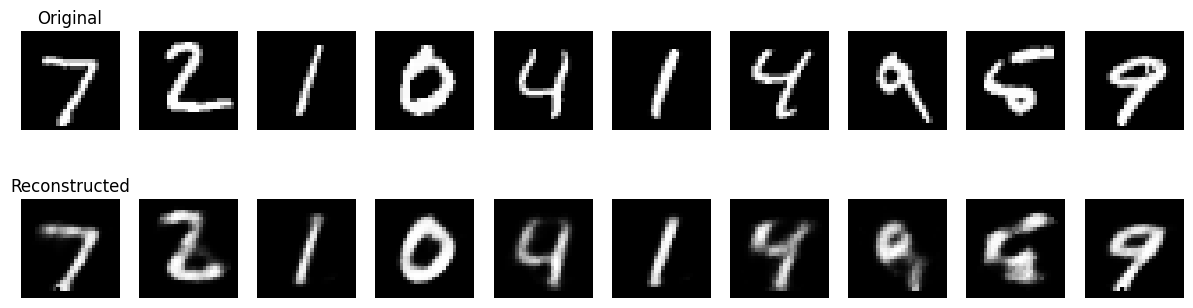

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


# Convert images to tensors
transform = transforms.ToTensor()


# Load MNIST training dataset
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)


# Load MNIST test dataset
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)


# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=10,
    shuffle=False
)


# Define Autoencoder
class Autoencoder(nn.Module):

    def __init__(self):
        super(Autoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


# Create model
model = Autoencoder()


# Loss function
criterion = nn.MSELoss()


# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


# Train the Autoencoder
epochs = 5

for epoch in range(epochs):

    total_loss = 0

    for data, _ in train_loader:

        # Forward pass
        output = model(data)

        # Calculate loss
        loss = criterion(output, data)

        # Clear previous gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch [{epoch + 1}/{epochs}], "
        f"Loss: {total_loss / len(train_loader):.4f}"
    )


# Get test images
data, _ = next(iter(test_loader))


# Reconstruct test images
with torch.no_grad():
    reconstructed = model(data)


# Display original and reconstructed images
fig, axes = plt.subplots(2, 10, figsize=(15, 4))

for i in range(10):

    # Original image
    axes[0, i].imshow(
        data[i].squeeze(),
        cmap='gray'
    )
    axes[0, i].axis('off')

    # Reconstructed image
    axes[1, i].imshow(
        reconstructed[i].squeeze(),
        cmap='gray'
    )
    axes[1, i].axis('off')


axes[0, 0].set_title("Original")
axes[1, 0].set_title("Reconstructed")

plt.show()